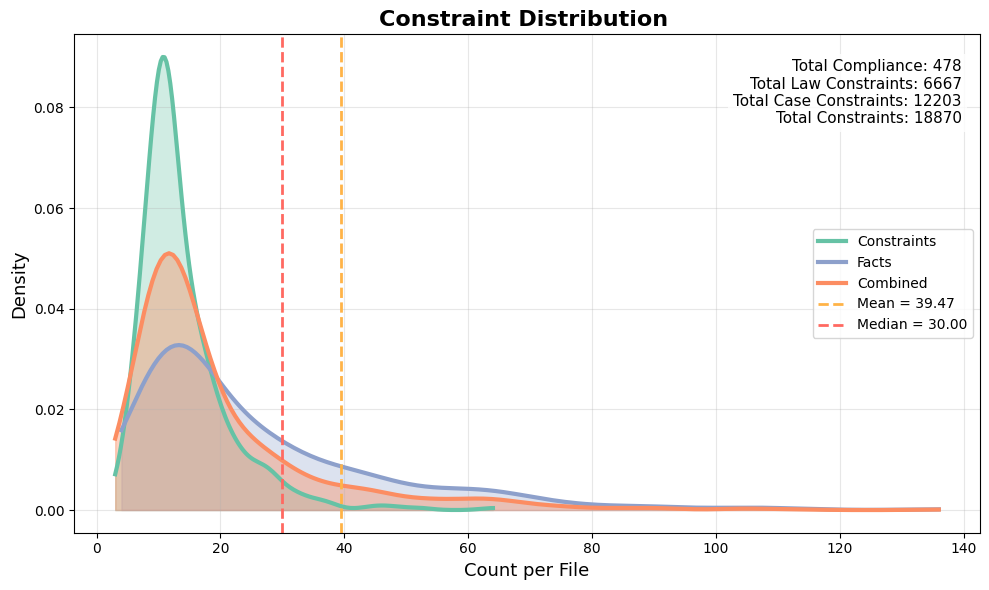

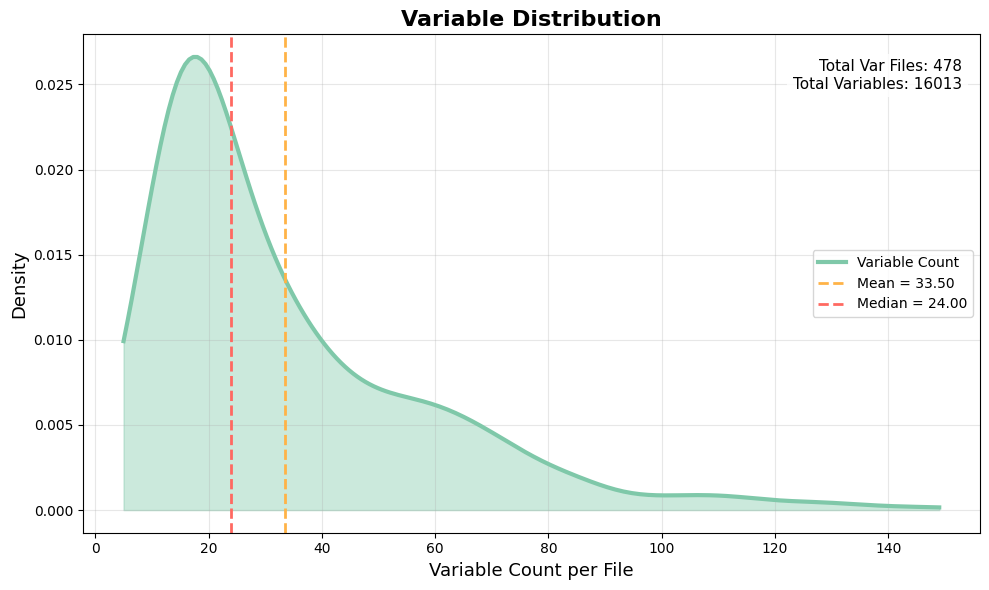


✓ Charts saved: three_layer_distribution.png & variable_distribution.png


In [30]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Set file search path
search_dir = r"./"

# Store statistics
constraint_stats = defaultdict(int)
facts_stats = defaultdict(int)
var_stats = defaultdict(int)

total_constraints = 0
total_facts = 0
total_vars = 0

# --- Scan files ---
for root, dirs, files in os.walk(search_dir):
    for file in files:
        path = os.path.join(root, file)

        # constraint files
        if file.startswith("case_") and file.endswith(".constraint_spec.json"):
            try:
                with open(path, "r", encoding="utf-8") as f:
                    data = json.load(f)
                count = len(data) if isinstance(data, list) else 1
                constraint_stats[file] = count
                total_constraints += count
            except Exception:
                pass

        # facts files
        elif file.startswith("case_") and file.endswith(".facts.json"):
            try:
                with open(path, "r", encoding="utf-8") as f:
                    data = json.load(f)
                count = len(data) if isinstance(data, dict) else 1
                facts_stats[file] = count
                total_facts += count
            except Exception:
                pass

        # variable spec files
        elif file.startswith("case_") and file.endswith(".varspecs.json"):
            try:
                with open(path, "r", encoding="utf-8") as f:
                    data = json.load(f)
                count = len(data) if isinstance(data, list) else 1
                var_stats[file] = count
                total_vars += count
            except Exception:
                pass

# --- Prepare data ---
constraint_counts = list(constraint_stats.values())
facts_counts = list(facts_stats.values())
var_counts = list(var_stats.values())
all_counts = constraint_counts + facts_counts

total_files = len(constraint_stats) + len(facts_stats)
total_items = total_constraints + total_facts

# --- Helper function ---
def plot_kde(data, color, label, alpha=0.3, linewidth=3):
    if len(data) == 0:
        return None, None, None
    x_vals = np.linspace(min(data), max(data), 200)
    kde = gaussian_kde(data)
    y_vals = kde(x_vals)
    plt.plot(x_vals, y_vals, color=color, linewidth=linewidth, label=label)
    plt.fill_between(x_vals, y_vals, color=color, alpha=alpha)
    return x_vals, y_vals, kde

# --- 1️⃣ Three-layer distribution (constraints + facts + combined) ---
plt.figure(figsize=(10, 6))

plot_kde(constraint_counts, "#66c2a5", "Constraints")
plot_kde(facts_counts, "#8da0cb", "Facts")
plot_kde(all_counts, "#fc8d62", "Combined", alpha=0.4)

# Mean / Median
mean_val = np.mean(all_counts)
median_val = np.median(all_counts)
plt.axvline(39.47, color="#ffb347", linestyle="--", linewidth=2, label=f"Mean = {39.47:.2f}")
plt.axvline(30, color="#ff6961", linestyle="--", linewidth=2, label=f"Median = {30:.2f}")

plt.title("Constraint Distribution ", fontsize=16, fontweight="bold")
plt.xlabel("Count per File", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.grid(alpha=0.3)
plt.legend()

# Info box
info = (
    f"Total Compliance: 478\n"
    f"Total Law Constraints: {total_constraints}\n"
    f"Total Case Constraints: {total_facts}\n"
    f"Total Constraints: {total_items}"
)
plt.text(0.98, 0.95, info, fontsize=11, ha="right", va="top",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

plt.tight_layout()
plt.savefig("three_layer_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2️⃣ Variable count distribution ---
if len(var_counts) > 0:
    plt.figure(figsize=(10, 6))

    x_vals, y_vals, kde = plot_kde(var_counts, "#7fc8a9", "Variable Count", alpha=0.4)
    mean_vars = np.mean(var_counts)
    median_vars = np.median(var_counts)
    plt.axvline(mean_vars, color="#ffb347", linestyle="--", linewidth=2, label=f"Mean = {mean_vars:.2f}")
    plt.axvline(median_vars, color="#ff6961", linestyle="--", linewidth=2, label=f"Median = {median_vars:.2f}")

    plt.title("Variable Distribution", fontsize=16, fontweight="bold")
    plt.xlabel("Variable Count per File", fontsize=13)
    plt.ylabel("Density", fontsize=13)
    plt.grid(alpha=0.3)
    plt.legend()

    info_vars = (
        f"Total Var Files: 478\n"
        f"Total Variables: 16013"
    )
    plt.text(0.98, 0.95, info_vars, fontsize=11, ha="right", va="top",
             transform=plt.gca().transAxes,
             bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

    plt.tight_layout()
    plt.savefig("variable_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

print("\n✓ Charts saved: three_layer_distribution.png & variable_distribution.png")


In [23]:
import json
import os
from collections import defaultdict
import pandas as pd
import numpy as np

# Set file search path
search_dir = r"./"

# Store statistics
case_stats = {}

# --- Scan files ---
for root, dirs, files in os.walk(search_dir):
    for file in files:
        path = os.path.join(root, file)
        
        # Extract case number from filename
        if file.startswith("case_") and "_" in file:
            case_num = file.split("_")[1].split(".")[0]
            
            if case_num not in case_stats:
                case_stats[case_num] = {
                    "case": case_num,
                    "#Var": 0,
                    "Real": 0,
                    "Int": 0,
                    "Bool": 0,
                    "#Con": 0,
                    "Hard": 0,
                    "Soft": 0,
                }
            
            # Process variable spec files
            if file.endswith(".varspecs.json"):
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        data = json.load(f)
                    
                    var_count = len(data) if isinstance(data, list) else 0
                    case_stats[case_num]["#Var"] = var_count
                    
                    # Count variable types
                    for var in data:
                        var_type = var.get("type", "").lower()
                        if "real" in var_type or "float" in var_type:
                            case_stats[case_num]["Real"] += 1
                        elif "int" in var_type:
                            case_stats[case_num]["Int"] += 1
                        elif "bool" in var_type:
                            case_stats[case_num]["Bool"] += 1
                except Exception:
                    pass
            
            # Process constraint files (Hard constraints)
            elif file.endswith(".constraint_spec.json"):
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        data = json.load(f)
                    
                    constraint_count = len(data) if isinstance(data, list) else 0
                    case_stats[case_num]["#Con"] = constraint_count
                    case_stats[case_num]["Hard"] = constraint_count
                except Exception:
                    pass
            
            # Process facts files (Soft constraints)
            elif file.endswith(".facts.json"):
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        data = json.load(f)
                    
                    facts_count = len(data) if isinstance(data, dict) else 0
                    case_stats[case_num]["Soft"] = facts_count
                except Exception:
                    pass

# --- Calculate totals and ratios ---
for case_num in case_stats:
    hard_count = case_stats[case_num]["Hard"]
    soft_count = case_stats[case_num]["Soft"]
    total_constraints = hard_count + soft_count
    
    case_stats[case_num]["#Con"] = total_constraints
    case_stats[case_num]["H_Ratio"] = round(hard_count / total_constraints * 100, 2) if total_constraints > 0 else 0
    case_stats[case_num]["S_Ratio"] = round(soft_count / total_constraints * 100, 2) if total_constraints > 0 else 0

df = pd.DataFrame(list(case_stats.values()))
df = df.sort_values("case").reset_index(drop=True)

# Remove rows where all constraint and variable counts are zero
df = df[(df["#Var"] > 0) | (df["#Con"] > 0)].reset_index(drop=True)

# Display detailed table
print("\n" + "="*120)
print("DETAILED CASE STATISTICS")
print("="*120)
print(df.to_string(index=False))

# --- Calculate summary statistics ---
numeric_cols = ["#Var", "Real", "Int", "Bool", "#Con", "Hard", "Soft", "H_Ratio", "S_Ratio"]
summary_stats = {
    "Metric": numeric_cols,
    "Min": [df[col].min() for col in numeric_cols],
    "Max": [df[col].max() for col in numeric_cols],
    "Mean": [round(df[col].mean(), 2) for col in numeric_cols],
    "Median": [df[col].median() for col in numeric_cols],
    "Std": [round(df[col].std(), 2) for col in numeric_cols]
}

summary_df = pd.DataFrame(summary_stats)

print("\n" + "="*120)
print("SUMMARY STATISTICS (Min / Max / Mean / Median / Std)")
print("="*120)
print(summary_df.to_string(index=False))

# Save to CSV
df.to_csv("case_statistics.csv", index=False)
summary_df.to_csv("summary_statistics.csv", index=False)

print("\n✓ Statistics saved: case_statistics.csv & summary_statistics.csv")


DETAILED CASE STATISTICS
case  #Var  Real  Int  Bool  #Con  Hard  Soft  H_Ratio  S_Ratio
   0    20     5    1    14    21     6    15    28.57    71.43
   1    10     0    0    10    18    11     7    61.11    38.89
  10    10     0    0    10    18    11     7    61.11    38.89
 100    16     0    0    16    24    11    13    45.83    54.17
 101    16     0    0    16    24    11    13    45.83    54.17
 102    13     0    0    13    23    10    13    43.48    56.52
 103    65    13    0    52    76    15    61    19.74    80.26
 104    11     0    0    11    13     8     5    61.54    38.46
 105    74     3    2    69    87    18    69    20.69    79.31
 106    61     1    2    58    79    19    60    24.05    75.95
 107    69     2    1    66    82    15    67    18.29    81.71
 108    32     3    1    28    48    16    32    33.33    66.67
 109    53    19    3    31    56    17    39    30.36    69.64
  11    35     3    1    31    46    12    34    26.09    73.91
 110    28    

=== Confusion Matrix ===
            Pred_SAT  Pred_UNSAT
True_SAT         316           2
True_UNSAT       132          29

=== Classification Report ===
              precision    recall  f1-score   support

         SAT      0.705     0.994     0.825       318
       UNSAT      0.935     0.180     0.302       161

    accuracy                          0.720       479
   macro avg      0.820     0.587     0.564       479
weighted avg      0.783     0.720     0.649       479



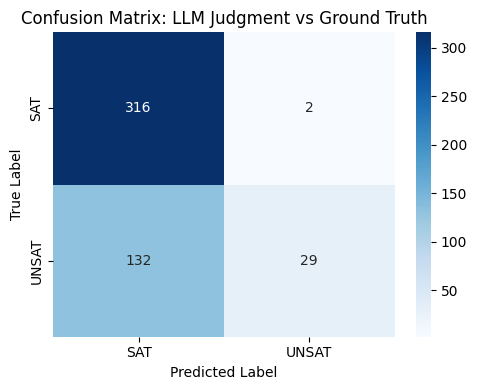

In [31]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. 讀取 Excel 檔 ===
file_path = "rq3_llm_correction_results_20251101_164127.xlsx"
sheet_name = "results"  # 改成實際的 sheet 名稱
df = pd.read_excel(file_path, sheet_name=sheet_name)

# === 2. 清理資料 ===
y_true = df["ground_truth_result"].astype(str).str.strip().str.upper()
y_pred = df["llm_judgment"].astype(str).str.strip().str.upper()

# === 3. 計算混淆矩陣 ===
labels = ["SAT", "UNSAT"]  # 固定順序
cm = confusion_matrix(y_true, y_pred, labels=labels)

# === 4. 印出文字報告 ===
print("=== Confusion Matrix ===")
print(pd.DataFrame(cm, index=[f"True_{l}" for l in labels], columns=[f"Pred_{l}" for l in labels]))
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, labels=labels, digits=3))

# === 5. 視覺化 ===
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: LLM Judgment vs Ground Truth")
plt.tight_layout()
plt.show()
